# NAM Raman Analysis — Complete Pipeline

**N-Acetylmuramic acid: experimental Raman spectroscopy and DFT vibrational analysis**

Run every cell top to bottom. All figures are written to `figures/` at 300 dpi
with consistent styling.

| Section | What it does | Figures produced |
|---|---|---|
| 1 | Setup and configuration | — |
| 2 | Load all spectra and metadata | — |
| 3 | Preprocessing functions | — |
| 4 | Process everything, quality control | `figS1_qc_overview` |
| 5 | Acquisition-parameter survey | `fig3_optimisation` |
| 6 | Photostability and laser damage | `fig4_photostability` |
| 7 | Correlation between measurement sets | `figS2_correlation` |
| 8 | Build the reference spectrum | `fig2_reference` |
| 9 | Peak extraction and validation | `figS3_peak_validation` |
| 10 | DFT: load, scale, broaden | `fig5_simulated` |
| 11 | Experiment vs theory | `fig6_overlay` |
| 12 | The 730 cm⁻¹ region | `fig7_region730` |
| 13 | Export tables | — |

`fig1_structure` is produced separately from the optimised geometry.

## 1. Setup and configuration

In [1]:
import os, csv, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.sparse import diags, csc_matrix
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter, find_peaks
warnings.filterwarnings("ignore")

# ---- paths (relative to the archive root) ----
ROOT   = ".."                       # NAM_Raman_Archive/
DATA   = f"{ROOT}/01_Raman_Data"
DFTDIR = f"{ROOT}/02_DFT_Calculation"
OUT    = "figures"
TABOUT = "tables"
os.makedirs(OUT, exist_ok=True)
os.makedirs(TABOUT, exist_ok=True)

# ---- analysis parameters (single source of truth) ----
CFG = dict(
    GRID_LO      = 400.0,   # fingerprint window, cm-1
    GRID_HI      = 1800.0,
    GRID_STEP    = 1.0,
    ALS_LAMBDA   = 1e5,     # baseline
    ALS_P        = 0.001,
    ALS_ITER     = 10,
    SG_WINDOW    = 11,      # smoothing
    SG_ORDER     = 3,
    NOISE_REGION = 1750.0,  # signal-free region for global SNR
    LOCAL_NOISE_HALFWIDTH = 50,   # points, for per-peak noise
    PEAK_PROMINENCE = 0.008,
    PEAK_DISTANCE   = 6,
    SNR_THRESHOLD   = 3.0,  # peak must exceed this x local noise
    REPRO_MIN       = 0.5,  # must appear in >=50% of replicate spectra
    MATCH_TOL       = 18.0, # cm-1, experiment <-> theory
    SCALE_LO        = 0.980,# frequency scaling below 1800 cm-1
    SCALE_HI        = 0.967,
    LORENTZ_FWHM    = 10.0,
    LASER_NM        = 785.0,
    TEMP_K          = 298.15,
)

# ---- which sets build what ----
REFERENCE_SETS = ["R2", "R4"]        # 22 fresh-spot spectra, 10 s
VALIDATION_SETS = ["R6", "R7", "R8"] # 11 spectra, 30-60 s, high SNR
GRID_SET       = ["GRID"]
PHOTOSTAB_SET  = ["SS1"]
DAMAGE_SETS    = ["DMG1", "DMG2"]

GRID = np.arange(CFG["GRID_LO"], CFG["GRID_HI"] + CFG["GRID_STEP"], CFG["GRID_STEP"])

# ---- consistent plot style for every figure ----
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.linewidth": 0.9, "axes.grid": False,
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "figure.dpi": 110,
})
C = dict(exp="#1f3864", sim="#c0392b", ok="#2ecc71", bad="#c0392b",
         warn="#e67e22", grey="#666666")

def save(fig, name):
    p = f"{OUT}/{name}.png"
    fig.savefig(p, dpi=300, bbox_inches="tight")
    print(f"saved  {p}")

print("configured. grid:", GRID[0], "-", GRID[-1], "cm-1,", len(GRID), "points")

configured. grid: 400.0 - 1800.0 cm-1, 1401 points


## 2. Load all spectra

Reads the B&W Tek CSV format: ~98 lines of instrument metadata, then a header
row beginning `Pixel`, then the data. We use the `Raman Shift` and
`Dark Subtracted #1` columns.

In [2]:
def read_bwtek(path):
    """Return (metadata dict, x, y) from a B&W Tek CSV."""
    meta, hdr, rows = {}, None, []
    with open(path, errors="ignore") as f:
        for line in f:
            parts = next(csv.reader([line]))
            if hdr is None:
                if parts and parts[0] == "Pixel":
                    hdr = parts
                elif len(parts) >= 2:
                    meta[parts[0]] = parts[1]
            else:
                rows.append(parts)
    d = pd.DataFrame(rows, columns=hdr)
    x = pd.to_numeric(d["Raman Shift"], errors="coerce")
    y = pd.to_numeric(d["Dark Subtracted #1"], errors="coerce")
    m = x.notna() & y.notna()
    return meta, x[m].values, y[m].values

index = pd.read_csv(f"{ROOT}/FILE_INDEX.csv")
print(f"{len(index)} files in index")
display(index.groupby(["folder", "set_code"])
        .agg(n=("filename", "size"), power=("power_pct", "first"),
             integ=("integration_s", "first"), acc=("accumulations", "first")))

227 files in index


n  power  integ  acc
folder                    set_code                       
A_Optimisation_Grid_April GRID      98      5      5    2
B_Replicates_May          R1        11     70     10    3
                          R2        11     70     10    5
                          R3        12     90     10    3
                          R4        11     90     10    5
                          R5        10     70     10    5
                          R6         3     70     30    5
                          R7         3     70     60    5
                          R8         5     90     30    5
                          R9        38      5      5    1
C_Photostability_May      SS1       10     90     30    5
D_Glass_Blanks            BLANK      5      5      5    1
E_EXCLUDED_Laser_Damage   DMG1       5     90     60    5
                          DMG2       5     90     60    5

## 3. Preprocessing

Identical treatment for every spectrum, in this order:

1. interpolate onto a uniform 1 cm⁻¹ grid, 400–1800
2. asymmetric least-squares baseline removal
3. Savitzky–Golay smoothing
4. min–max normalisation

Parameters come from `CFG` so nothing can drift between figures.

In [3]:
def als_baseline(y, lam=None, p=None, niter=None):
    """Asymmetric least squares baseline (Eilers & Boelens)."""
    lam = lam or CFG["ALS_LAMBDA"]; p = p or CFG["ALS_P"]; niter = niter or CFG["ALS_ITER"]
    L = len(y)
    D = diags([1, -2, 1], [0, -1, -2], shape=(L, L - 2))
    D = lam * D.dot(D.T)
    w = np.ones(L); W = diags(w, 0); z = y
    for _ in range(niter):
        W.setdiag(w)
        z = spsolve(csc_matrix(W + D), w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return z

def preprocess(x, y):
    """Raw (x, y) -> normalised spectrum on GRID."""
    o = np.argsort(x); x, y = x[o], y[o]
    yi = np.interp(GRID, x, y)
    corrected = yi - als_baseline(yi)
    smoothed = savgol_filter(corrected, CFG["SG_WINDOW"], CFG["SG_ORDER"])
    return (smoothed - smoothed.min()) / (smoothed.max() - smoothed.min() + 1e-12)

def global_snr(spec):
    """Max band height above median, divided by noise in the signal-free region."""
    noise = np.std(np.diff(spec[GRID > CFG["NOISE_REGION"]])) / np.sqrt(2)
    return (spec.max() - np.median(spec)) / (noise + 1e-12)

def local_noise(spec, i, half=None):
    half = half or CFG["LOCAL_NOISE_HALFWIDTH"]
    lo, hi = max(0, i - half), min(len(spec), i + half)
    return np.std(np.diff(spec[lo:hi])) / np.sqrt(2)

print("preprocessing functions ready")

preprocessing functions ready


## 4. Process everything and check quality

In [4]:
spectra, records = {}, []
for r in index.itertuples():
    path = f"{DATA}/{r.folder}/{r.filename}"
    try:
        meta, x, y = read_bwtek(path)
        if len(x) < 500:
            continue
        s = preprocess(x, y)
        spectra[r.filename] = s
        records.append(dict(filename=r.filename, folder=r.folder, set_code=r.set_code,
                            sample=r.sample, power=r.power_pct, integ=r.integration_s,
                            acc=r.accumulations, snr=global_snr(s), date=r.date_time))
    except Exception as e:
        print("FAILED", r.filename, e)

P = pd.DataFrame(records)
PN = P[P["sample"] == "NAM powder"].copy()
print(f"processed {len(P)} spectra ({len(PN)} NAM powder, {len(P)-len(PN)} glass)")

summary = (PN.groupby(["set_code", "power", "integ", "acc"])
             .agg(n=("snr", "size"), snr_mean=("snr", "mean"), snr_sd=("snr", "std"))
             .round(1).sort_values("snr_mean", ascending=False))
display(summary.head(15))

processed 227 spectra (222 NAM powder, 5 glass)


n  snr_mean  snr_sd
set_code power integ acc                      
R7       70    60    5     3     632.8    81.1
SS1      90    30    5    10     492.5    76.7
R6       70    30    5     3     344.3    21.1
R8       90    30    5     5     324.3   180.6
GRID     75    25    2     1     287.3     NaN
         70    25    2     1     267.6     NaN
         60    25    2     1     263.6     NaN
         80    20    2     1     253.6     NaN
         65    20    2     1     227.0     NaN
         80    25    2     1     226.6     NaN
         55    25    2     1     218.7     NaN
R9       90    10    5     5     215.0    30.6
R4       90    10    5    11     201.3    41.8
GRID     50    20    2     1     192.1     NaN
R5       70    10    5    10     190.3    47.1

saved  figures/figS1_qc_overview.png


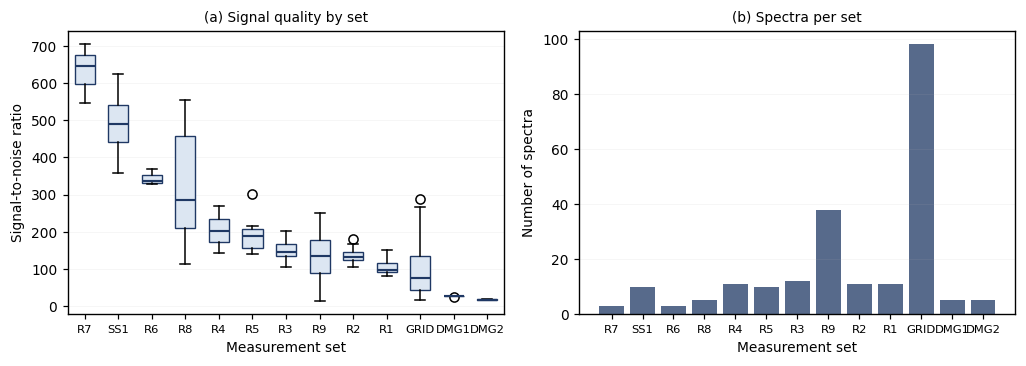

In [5]:
# --- figS1: dataset overview ---
fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.4))

order = PN.groupby("set_code").snr.median().sort_values(ascending=False).index
data = [PN[PN.set_code == s].snr.values for s in order]
bp = ax[0].boxplot(data, labels=order, patch_artist=True, widths=0.6)
for b in bp["boxes"]:
    b.set_facecolor("#dce6f2"); b.set_edgecolor(C["exp"]); b.set_linewidth(0.9)
for w in bp["medians"]: w.set_color(C["exp"]); w.set_linewidth(1.4)
ax[0].set_ylabel("Signal-to-noise ratio"); ax[0].set_xlabel("Measurement set")
ax[0].set_title("(a) Signal quality by set", fontsize=9)
ax[0].tick_params(axis="x", labelsize=7.5); ax[0].grid(alpha=0.15, lw=0.5, axis="y")

counts = PN.groupby("set_code").size().reindex(order)
ax[1].bar(range(len(counts)), counts.values, color=C["exp"], alpha=0.75)
ax[1].set_xticks(range(len(counts))); ax[1].set_xticklabels(counts.index, fontsize=7.5)
ax[1].set_ylabel("Number of spectra"); ax[1].set_xlabel("Measurement set")
ax[1].set_title("(b) Spectra per set", fontsize=9)
ax[1].grid(alpha=0.15, lw=0.5, axis="y")

plt.tight_layout(); save(fig, "figS1_qc_overview"); plt.show()

## 5. Acquisition-parameter survey

The April grid: 5 integration times × 16 laser powers. Establishes how SNR
depends on acquisition settings, and confirms band positions do not shift.

saved  figures/fig3_optimisation.png


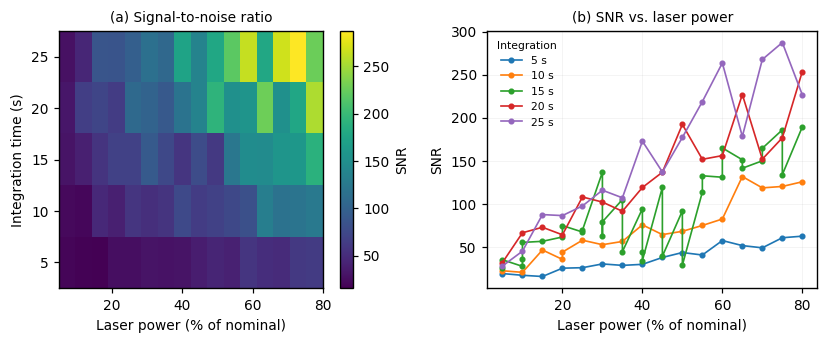

Band-position stability at 25 s, 5-80% power:
  930  cm-1: 929-930  (spread 1 cm-1)
  1451 cm-1: 1450-1452  (spread 2 cm-1)
  FWHM(930): 9-11 cm-1


In [6]:
gr = PN[PN.set_code.isin(GRID_SET)]

fig, ax = plt.subplots(1, 2, figsize=(7.6, 3.2))
pv = gr.pivot_table(index="integ", columns="power", values="snr", aggfunc="mean")
im = ax[0].imshow(pv.values, aspect="auto", origin="lower", cmap="viridis",
                  extent=[pv.columns.min(), pv.columns.max(), 0, len(pv.index)])
ax[0].set_yticks(np.arange(len(pv.index)) + 0.5)
ax[0].set_yticklabels([f"{i:.0f}" for i in pv.index])
ax[0].set_xlabel("Laser power (% of nominal)"); ax[0].set_ylabel("Integration time (s)")
ax[0].set_title("(a) Signal-to-noise ratio", fontsize=9)
plt.colorbar(im, ax=ax[0], label="SNR")

for t in sorted(gr.integ.unique()):
    s = gr[gr.integ == t].sort_values("power")
    ax[1].plot(s.power, s.snr, marker="o", ms=3, lw=1.1, label=f"{t:.0f} s")
ax[1].set_xlabel("Laser power (% of nominal)"); ax[1].set_ylabel("SNR")
ax[1].legend(frameon=False, fontsize=7, title="Integration", title_fontsize=7)
ax[1].grid(alpha=0.18, lw=0.5); ax[1].set_title("(b) SNR vs. laser power", fontsize=9)

plt.tight_layout(); save(fig, "fig3_optimisation"); plt.show()

# band-position stability across the grid
def band_position(spec, target, window=12):
    pk, _ = find_peaks(spec, prominence=0.05, distance=8)
    c = pk[np.abs(GRID[pk] - target) < window]
    return GRID[c[np.argmax(spec[c])]] if len(c) else np.nan

stab = []
for r in gr[gr.integ == 25].sort_values("power").itertuples():
    s = spectra[r.filename]
    i = np.argmin(abs(GRID - 930)); half = s[i] / 2
    l = i
    while l > 0 and s[l] > half: l -= 1
    rr = i
    while rr < len(s) - 1 and s[rr] > half: rr += 1
    stab.append(dict(power=r.power, pos930=band_position(s, 930),
                     pos1451=band_position(s, 1451), fwhm930=GRID[rr] - GRID[l]))
S = pd.DataFrame(stab)
print("Band-position stability at 25 s, 5-80% power:")
print(f"  930  cm-1: {S.pos930.min():.0f}-{S.pos930.max():.0f}  (spread {S.pos930.max()-S.pos930.min():.0f} cm-1)")
print(f"  1451 cm-1: {S.pos1451.min():.0f}-{S.pos1451.max():.0f}  (spread {S.pos1451.max()-S.pos1451.min():.0f} cm-1)")
print(f"  FWHM(930): {S.fwhm930.min():.0f}-{S.fwhm930.max():.0f} cm-1")

## 6. Photostability and laser damage

Two same-spot series at 90% power: 30 s (stable) and 60 s (destroyed).

saved  figures/fig4_photostability.png


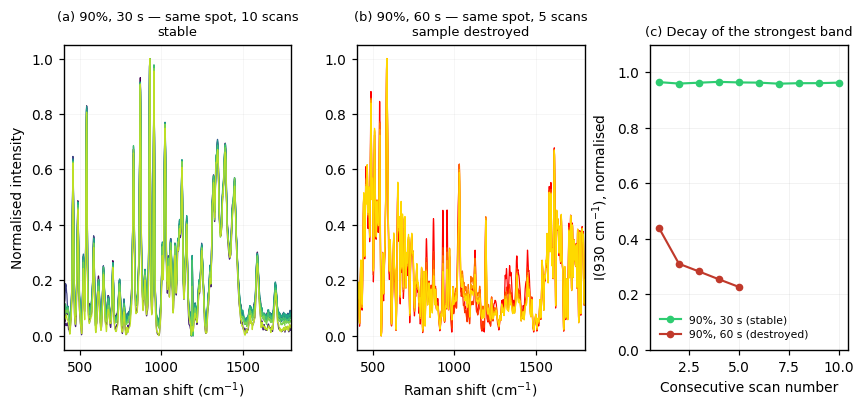

  SS1: I(930) 0.96 -> 0.96  over 10 scans
  DMG1: I(930) 0.44 -> 0.23  over 5 scans
  DMG2: I(930) 0.78 -> 0.45  over 5 scans


In [7]:
fig = plt.figure(figsize=(9.2, 3.6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.15, 1.15, 1], wspace=0.30)
a0, a1, a2 = [fig.add_subplot(gs[i]) for i in range(3)]

ss = PN[PN.set_code.isin(PHOTOSTAB_SET)].filename.tolist()
for c, f in zip(plt.cm.viridis(np.linspace(0, 0.9, len(ss))), ss):
    a0.plot(GRID, spectra[f], color=c, lw=0.8)
a0.set_title("(a) 90%, 30 s — same spot, 10 scans\nstable", fontsize=8.5)

dm = PN[PN.set_code == "DMG1"].filename.tolist()
for c, f in zip(plt.cm.autumn(np.linspace(0, 0.85, len(dm))), dm):
    a1.plot(GRID, spectra[f], color=c, lw=0.8)
a1.set_title("(b) 90%, 60 s — same spot, 5 scans\nsample destroyed", fontsize=8.5)

i930 = np.argmin(abs(GRID - 930))
for code_, lab, col in [(PHOTOSTAB_SET[0], "90%, 30 s (stable)", C["ok"]),
                        ("DMG1", "90%, 60 s (destroyed)", C["bad"])]:
    f = PN[PN.set_code == code_].filename.tolist()
    a2.plot(range(1, len(f) + 1), [spectra[x][i930] for x in f],
            marker="o", ms=4, lw=1.4, color=col, label=lab)
a2.set_xlabel("Consecutive scan number"); a2.set_ylabel("I(930 cm$^{-1}$), normalised")
a2.set_title("(c) Decay of the strongest band", fontsize=8.5)
a2.legend(frameon=False, fontsize=7); a2.grid(alpha=0.2, lw=0.5); a2.set_ylim(0, 1.1)

for a in (a0, a1):
    a.set_xlim(CFG["GRID_LO"], CFG["GRID_HI"]); a.set_xlabel("Raman shift (cm$^{-1}$)")
    a.grid(alpha=0.15, lw=0.5)
a0.set_ylabel("Normalised intensity")

plt.tight_layout(); save(fig, "fig4_photostability"); plt.show()

for code_ in PHOTOSTAB_SET + DAMAGE_SETS:
    f = PN[PN.set_code == code_].filename.tolist()
    v = [spectra[x][i930] for x in f]
    print(f"  {code_}: I(930) {v[0]:.2f} -> {v[-1]:.2f}  over {len(v)} scans")

## 7. Correlation between measurement sets

Are the sets mutually consistent? Any set that disagrees needs explaining before
it is used.

saved  figures/figS2_correlation.png


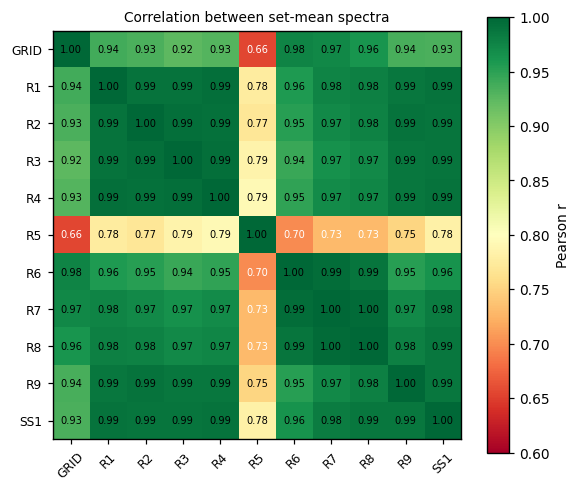

Sets correlating below 0.90 with the reference sets:
  R5: mean r = 0.782  <-- inspect before use


In [8]:
set_means = {}
for s in sorted(PN.set_code.unique()):
    if s in DAMAGE_SETS: continue
    M = np.array([spectra[f] for f in PN[PN.set_code == s].filename])
    m = M.mean(0); set_means[s] = (m - m.min()) / (m.max() - m.min())

ks = list(set_means)
Cm = pd.DataFrame([[np.corrcoef(set_means[a], set_means[b])[0, 1] for b in ks] for a in ks],
                  index=ks, columns=ks)

fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.imshow(Cm.values, cmap="RdYlGn", vmin=0.6, vmax=1.0)
ax.set_xticks(range(len(ks))); ax.set_xticklabels(ks, rotation=45, fontsize=8)
ax.set_yticks(range(len(ks))); ax.set_yticklabels(ks, fontsize=8)
for i in range(len(ks)):
    for j in range(len(ks)):
        ax.text(j, i, f"{Cm.values[i,j]:.2f}", ha="center", va="center", fontsize=6.5,
                color="black" if Cm.values[i, j] > 0.75 else "white")
plt.colorbar(im, label="Pearson r")
ax.set_title("Correlation between set-mean spectra", fontsize=9)
plt.tight_layout(); save(fig, "figS2_correlation"); plt.show()

print("Sets correlating below 0.90 with the reference sets:")
for s in ks:
    v = Cm.loc[s, REFERENCE_SETS].mean()
    if v < 0.90:
        print(f"  {s}: mean r = {v:.3f}  <-- inspect before use")

## 8. Reference spectrum

Built from `REFERENCE_SETS` — independent measurements on fresh sample at a
single integration time.

reference : n = 22 from sets ['R2', 'R4']
            mean pairwise r = 0.9855, SNR = 279
validation: n = 11 from sets ['R6', 'R7', 'R8'], SNR = 511


saved  figures/fig2_reference.png


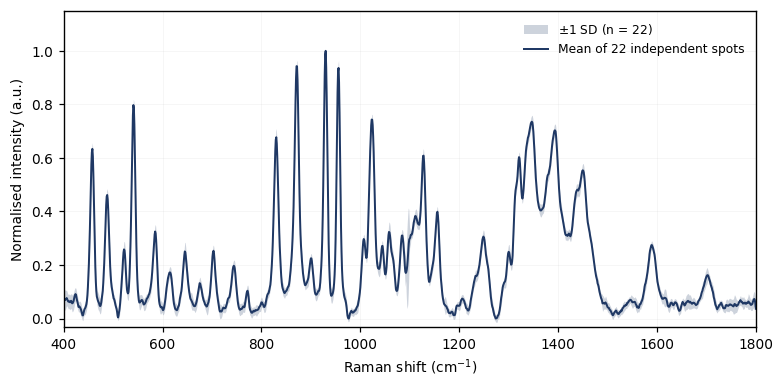

In [9]:
ref_files = PN[PN.set_code.isin(REFERENCE_SETS)].filename.tolist()
M = np.array([spectra[f] for f in ref_files])
mean = M.mean(0); sd = M.std(0)
mean = (mean - mean.min()) / (mean.max() - mean.min())

val_files = PN[PN.set_code.isin(VALIDATION_SETS)].filename.tolist()
ML = np.array([spectra[f] for f in val_files])
mlong = ML.mean(0); mlong = (mlong - mlong.min()) / (mlong.max() - mlong.min())

pw = np.corrcoef(M)[np.triu_indices(len(M), 1)].mean()
print(f"reference : n = {len(ref_files)} from sets {REFERENCE_SETS}")
print(f"            mean pairwise r = {pw:.4f}, SNR = {global_snr(mean):.0f}")
print(f"validation: n = {len(val_files)} from sets {VALIDATION_SETS}, SNR = {global_snr(mlong):.0f}")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.fill_between(GRID, mean - sd, mean + sd, color=C["exp"], alpha=0.22, lw=0,
                label=f"$\\pm$1 SD (n = {len(ref_files)})")
ax.plot(GRID, mean, color=C["exp"], lw=1.3,
        label=f"Mean of {len(ref_files)} independent spots")
ax.set_xlabel("Raman shift (cm$^{-1}$)"); ax.set_ylabel("Normalised intensity (a.u.)")
ax.set_xlim(CFG["GRID_LO"], CFG["GRID_HI"]); ax.set_ylim(-0.03, 1.15)
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.15, lw=0.5)
plt.tight_layout(); save(fig, "fig2_reference"); plt.show()

## 9. Peak extraction and validation

Two independent criteria against **local** noise, because baseline correction and
smoothing produce reproducible artefacts — a feature appearing in every spectrum
is not by itself evidence that it is real.

- **prominence** ≥ 3 × local noise
- **height above local median** ≥ 3 × local noise

Both → high confidence. One only → checked against the independent
long-integration data and promoted if confirmed. Neither → rejected.

In [10]:
pk, props = find_peaks(mean, prominence=CFG["PEAK_PROMINENCE"], distance=CFG["PEAK_DISTANCE"])
rows = []
pl, _ = find_peaks(mlong, prominence=CFG["PEAK_PROMINENCE"] * 0.75, distance=CFG["PEAK_DISTANCE"])

for j, i in enumerate(pk):
    nz = local_noise(mean, i)
    prom = props["prominences"][j]
    base = np.median(mean[max(0, i - 50): i + 50])
    height = mean[i] - base
    detected = sum(1 for r in M if np.any(np.abs(
        GRID[find_peaks(r, prominence=CFG["PEAK_PROMINENCE"], distance=CFG["PEAK_DISTANCE"])[0]] - GRID[i]) <= 4))
    nzl = local_noise(mlong, i)
    hl = mlong[i] - np.median(mlong[max(0, i - 50): i + 50])
    rows.append(dict(peak_cm1=GRID[i], rel_intensity=mean[i],
                     prom_snr=prom / max(nz, 1e-12),
                     height_snr=height / max(nz, 1e-12),
                     reproducibility=detected / len(M),
                     long_snr=hl / max(nzl, 1e-12),
                     confirmed_long=bool(np.any(np.abs(GRID[pl] - GRID[i]) <= 5))))
T = pd.DataFrame(rows)

t = CFG["SNR_THRESHOLD"]
both = (T.prom_snr >= t) & (T.height_snr >= t)
one  = (T.prom_snr >= t) | (T.height_snr >= t)
T["quality"] = np.where(both, "high",
               np.where(one & T.confirmed_long & (T.long_snr >= t), "high",
               np.where(one, "tentative", "reject")))
T = T[T.reproducibility >= CFG["REPRO_MIN"]]

print(T.quality.value_counts().to_string())
promoted = T[(T.quality == "high") & ~both.reindex(T.index, fill_value=False)]
print(f"\npromoted by long-integration confirmation: {len(promoted)}")
if len(promoted): display(promoted[["peak_cm1","prom_snr","height_snr","long_snr"]].round(2))
print("\nrejected:")
display(T[T.quality == "reject"][["peak_cm1","prom_snr","height_snr"]].round(2))

peaks = T[T.quality != "reject"].reset_index(drop=True)
print(f"\nFINAL: {len(peaks)} bands ({sum(peaks.quality=='high')} high, "
      f"{sum(peaks.quality=='tentative')} tentative)")

quality
high         32
tentative     9
reject        5

promoted by long-integration confirmation: 2


,peak_cm1,prom_snr,height_snr,long_snr
19,1007.0,2.45,3.46,4.30
24,1112.0,1.86,5.84,5.22



rejected:


,peak_cm1,prom_snr,height_snr
0,424.0,1.49,1.01
5,558.0,0.35,-1.04
13,800.0,0.95,-0.20
16,901.0,2.44,1.02
38,1629.0,1.89,-0.30



FINAL: 41 bands (32 high, 9 tentative)


saved  figures/figS3_peak_validation.png


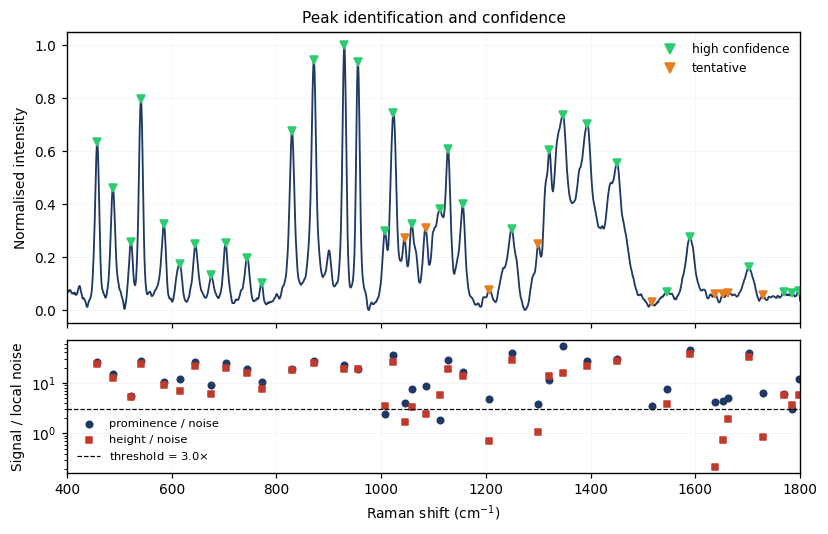

In [11]:
# --- figS3: peak validation ---
fig, ax = plt.subplots(2, 1, figsize=(8.6, 5.2), sharex=True,
                       gridspec_kw={"height_ratios":[2.2,1], "hspace":0.08})
ax[0].plot(GRID, mean, color=C["exp"], lw=1.2)
for r in peaks.itertuples():
    i = np.argmin(abs(GRID - r.peak_cm1))
    col = C["ok"] if r.quality == "high" else C["warn"]
    ax[0].plot(GRID[i], mean[i], "v", color=col, ms=5)
ax[0].plot([], [], "v", color=C["ok"], label="high confidence")
ax[0].plot([], [], "v", color=C["warn"], label="tentative")
ax[0].set_ylabel("Normalised intensity"); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title("Peak identification and confidence", fontsize=10)

ax[1].scatter(peaks.peak_cm1, peaks.prom_snr, s=18, color=C["exp"], label="prominence / noise")
ax[1].scatter(peaks.peak_cm1, peaks.height_snr, s=18, color=C["sim"], marker="s",
              label="height / noise")
ax[1].axhline(t, color="k", ls="--", lw=0.8, label=f"threshold = {t}$\\times$")
ax[1].set_yscale("log"); ax[1].set_ylabel("Signal / local noise")
ax[1].set_xlabel("Raman shift (cm$^{-1}$)"); ax[1].legend(frameon=False, fontsize=7.5)
for a in ax: a.set_xlim(CFG["GRID_LO"], CFG["GRID_HI"]); a.grid(alpha=0.15, lw=0.5)
save(fig, "figS3_peak_validation"); plt.show()

## 10. DFT: load, scale, broaden

Parses the Gaussian log directly — frequencies, Raman activities, and the
Cartesian displacement vectors needed for mode assignment.

In [12]:
LOG = f"{DFTDIR}/NAM_beta_Gaussian16_B3LYP-D3BJ_6-311++Gdp.log"
txt = open(LOG, errors="ignore").read()

# atoms, from the last standard orientation block
last = txt.split("Standard orientation:")[-1].split("\n")[5:]
Z2S = {1:"H", 6:"C", 7:"N", 8:"O"}
atoms = []
for ln in last:
    if "---" in ln: break
    p = ln.split()
    if len(p) >= 6:
        atoms.append((Z2S.get(int(p[1]), p[1]), float(p[3]), float(p[4]), float(p[5])))
natoms = len(atoms)

freqs, rams, irs, modes = [], [], [], []
sec = txt[txt.find("Harmonic frequencies"):]
for ch in sec.split(" Frequencies --")[1:]:
    head = ch.split("\n")
    f = [float(v) for v in head[0].split()]
    freqs += f
    for ln in head:
        st = ln.strip()
        if st.startswith("IR Inten"):    irs  += [float(v) for v in ln.split("--")[1].split()]
        if st.startswith("Raman Activ"): rams += [float(v) for v in ln.split("--")[1].split()]
    di = next((k+1 for k, ln in enumerate(head) if ln.strip().startswith("Atom  AN")), None)
    if di:
        disp = np.zeros((len(f), natoms, 3))
        for a in range(natoms):
            q = head[di + a].split()
            for m_ in range(len(f)):
                disp[m_, a, :] = [float(q[2+m_*3]), float(q[3+m_*3]), float(q[4+m_*3])]
        modes += [disp[m_] for m_ in range(len(f))]

n = len(freqs)
print(f"{natoms} atoms, {n} modes, {sum(1 for f in freqs if f < 0)} imaginary")

scale = lambda f: f * (CFG["SCALE_LO"] if f < 1800 else CFG["SCALE_HI"])
D = pd.DataFrame({"mode": range(1, n+1), "freq": freqs,
                  "raman": rams[:n], "ir": irs[:n]})
D["freq_scaled"] = D.freq.apply(scale)

# Placzek intensities at the excitation wavelength
nu0 = 1e7 / CFG["LASER_NM"]
h, c_, kB = 6.62607015e-34, 2.99792458e10, 1.380649e-23
def placzek(nu, S):
    if nu <= 0: return 0.0
    B = 1 - np.exp(-h * c_ * nu / (kB * CFG["TEMP_K"]))
    return S * (nu0 - nu)**4 / (nu * B)
D["intensity"] = [placzek(r.freq_scaled, r.raman) for r in D.itertuples()]
win = D[(D.freq_scaled >= CFG["GRID_LO"]) & (D.freq_scaled <= CFG["GRID_HI"])]
D["intensity"] /= win.intensity.max()

def lorentzian(grid, modes_, fwhm=None):
    g = (fwhm or CFG["LORENTZ_FWHM"]) / 2
    y = np.zeros_like(grid)
    for f, I in modes_: y += I * g**2 / ((grid - f)**2 + g**2)
    return y

sim = lorentzian(GRID, [(r.freq_scaled, r.intensity) for r in D.itertuples()
                        if 350 < r.freq_scaled < 1850])
sim /= sim.max()
print(f"{len(win)} modes in the fingerprint window")

39 atoms, 111 modes, 0 imaginary
67 modes in the fingerprint window


saved  figures/fig5_simulated.png


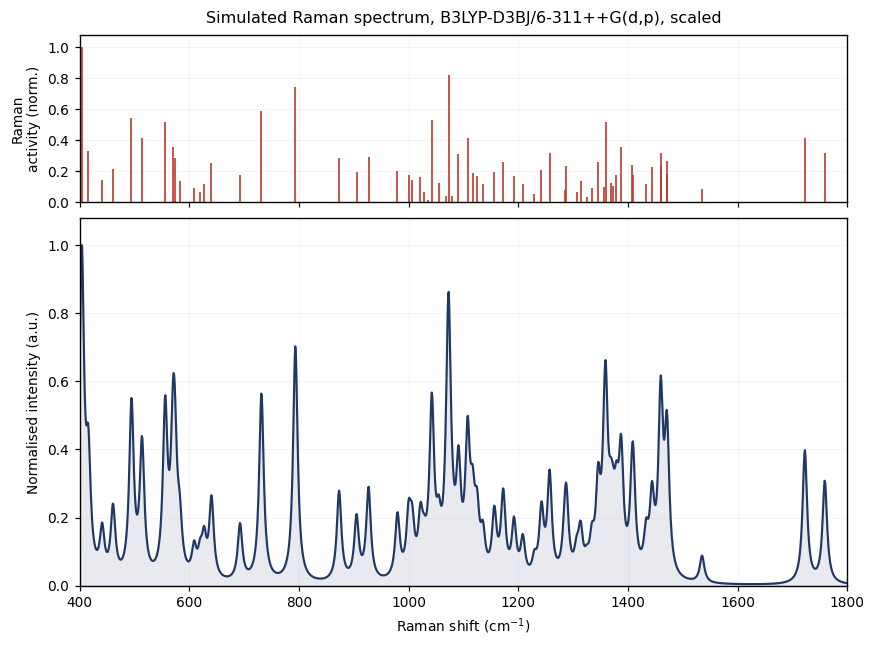

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True,
                       gridspec_kw={"height_ratios":[1, 2.2], "hspace":0.06})
st = D[(D.freq_scaled >= CFG["GRID_LO"]) & (D.freq_scaled <= CFG["GRID_HI"])]
ax[0].vlines(st.freq_scaled, 0, st.intensity, color=C["sim"], lw=1.1)
ax[0].set_ylabel("Raman\nactivity (norm.)", fontsize=9); ax[0].set_ylim(0, 1.08)
ax[0].set_title("Simulated Raman spectrum, B3LYP-D3BJ/6-311++G(d,p), scaled",
                fontsize=10.5, pad=8)
ax[1].plot(GRID, sim, color=C["exp"], lw=1.4)
ax[1].fill_between(GRID, 0, sim, color=C["exp"], alpha=0.10)
ax[1].set_xlabel("Raman shift (cm$^{-1}$)"); ax[1].set_ylabel("Normalised intensity (a.u.)")
ax[1].set_xlim(CFG["GRID_LO"], CFG["GRID_HI"]); ax[1].set_ylim(0, 1.08)
for a in ax: a.grid(alpha=0.18, lw=0.5)
save(fig, "fig5_simulated"); plt.show()

### Mode character from displacement vectors

For each mode, the fraction of mass-weighted displacement carried by each atom
and by the pyranose ring. This is what distinguishes, for example, a ring
breathing mode from a hydroxymethyl wag at similar frequency.

In [14]:
from itertools import combinations
sym = [a[0] for a in atoms]
xyz = np.array([[a[1], a[2], a[3]] for a in atoms])
COV = {"H":0.31, "C":0.76, "N":0.71, "O":0.66}
bonds = [(i, j) for i, j in combinations(range(natoms), 2)
         if np.linalg.norm(xyz[i]-xyz[j]) < 1.3*(COV[sym[i]]+COV[sym[j]])]
nbr = {i: [] for i in range(natoms)}
for i, j in bonds: nbr[i].append(j); nbr[j].append(i)

def find_ring():
    for start in [i for i in range(natoms) if sym[i] != "H"]:
        stack = [(start, [start])]
        while stack:
            cur, path = stack.pop()
            if len(path) > 6: continue
            for nx in nbr[cur]:
                if sym[nx] == "H": continue
                if nx == start and len(path) == 6: return sorted(path)
                if nx not in path: stack.append((nx, path + [nx]))
    return []
ring = find_ring()

def describe_mode(m):
    d = modes[m-1]; mag = np.linalg.norm(d, axis=1); tot = (mag**2).sum()
    heavy = [i for i in range(natoms) if sym[i] != "H"]
    top = np.argsort(-mag)[:5]
    return dict(mode=m, freq_scaled=D.loc[D["mode"]==m, "freq_scaled"].iloc[0],
                ring_pct=100*(mag[ring]**2).sum()/tot,
                heavy_pct=100*(mag[heavy]**2).sum()/tot,
                top_atoms=[(int(i), sym[i], round(100*mag[i]**2/tot, 1)) for i in top])

print(f"pyranose ring atoms: {ring}\n")
for target in [731, 873, 927]:
    m = int(D.iloc[(D.freq_scaled - target).abs().argsort().iloc[0]]["mode"])
    r = describe_mode(m)
    print(f"mode {r['mode']} at {r['freq_scaled']:.1f} cm-1")
    print(f"   ring {r['ring_pct']:.1f}%   heavy atoms {r['heavy_pct']:.1f}%")
    print(f"   dominant: {r['top_atoms']}\n")

pyranose ring atoms: [0, 9, 10, 11, 12, 13]

mode 41 at 731.3 cm-1
   ring 0.5%   heavy atoms 24.0%
   dominant: [(38, 'H', np.float64(47.9)), (18, 'C', np.float64(14.4)), (28, 'H', np.float64(12.2)), (31, 'H', np.float64(10.9)), (7, 'O', np.float64(3.3))]

mode 43 at 873.0 cm-1
   ring 5.0%   heavy atoms 8.9%
   dominant: [(26, 'H', np.float64(45.9)), (25, 'H', np.float64(17.4)), (34, 'H', np.float64(10.1)), (23, 'H', np.float64(8.8)), (32, 'H', np.float64(3.0))]

mode 45 at 926.7 cm-1
   ring 7.1%   heavy atoms 27.6%
   dominant: [(27, 'H', np.float64(17.5)), (37, 'H', np.float64(11.4)), (35, 'H', np.float64(11.3)), (29, 'H', np.float64(9.9)), (21, 'H', np.float64(9.4))]



## 11. Experiment vs theory

Each observed band is matched to the calculated mode of highest Raman activity
within `MATCH_TOL`. Unmatched bands are reported, not discarded — reporting the
statistic over matched bands only, with a narrow tolerance, produces an
artificially small error.

In [15]:
Dw = D[(D.freq_scaled >= CFG["GRID_LO"] - 10) & (D.freq_scaled <= CFG["GRID_HI"] + 20)]
rows = []
for e in peaks.itertuples():
    cand = Dw[abs(Dw.freq_scaled - e.peak_cm1) <= CFG["MATCH_TOL"]]
    if len(cand) == 0:
        rows.append(dict(exp=e.peak_cm1, calc=np.nan, delta=np.nan, raman_act=np.nan,
                         rel_int=e.rel_intensity, repro=e.reproducibility, quality=e.quality))
    else:
        b = cand.sort_values("raman", ascending=False).iloc[0]
        rows.append(dict(exp=e.peak_cm1, calc=b.freq_scaled, delta=e.peak_cm1-b.freq_scaled,
                         raman_act=b.raman, rel_int=e.rel_intensity,
                         repro=e.reproducibility, quality=e.quality))
comp = pd.DataFrame(rows).sort_values("exp").reset_index(drop=True)
m = comp.dropna(subset=["calc"])

stats = dict(bands=len(comp), matched=len(m),
             MAE=m.delta.abs().mean(), RMSE=np.sqrt((m.delta**2).mean()),
             max_abs=m.delta.abs().max(), r=np.corrcoef(m.exp, m.calc)[0,1],
             mean_signed=m.delta.mean())
for k, v in stats.items():
    print(f"  {k:12s} {v:.4f}" if isinstance(v, float) else f"  {k:12s} {v}")
print(f"\n  unmatched: {', '.join(f'{v:.0f}' for v in comp[comp.calc.isna()].exp)}")

# tolerance sensitivity - shows the statistic is not an artefact of the window
print("\n  tolerance sensitivity:")
for tol in [5, 10, 18, 25, 40]:
    d = []
    for e in peaks.itertuples():
        c = Dw[abs(Dw.freq_scaled - e.peak_cm1) <= tol]
        if len(c): d.append(e.peak_cm1 - c.sort_values("raman", ascending=False).iloc[0].freq_scaled)
    print(f"    +/-{tol:2d} cm-1: {len(d):2d} matched, RMSE {np.sqrt(np.mean(np.square(d))):5.2f} cm-1")

  bands        41
  matched      30
  MAE          9.2747
  RMSE         10.2851
  max_abs      17.1882
  r            0.9996
  mean_signed  1.5892

  unmatched: 772, 830, 956, 1517, 1589, 1637, 1652, 1663, 1702, 1785, 1797

  tolerance sensitivity:
    +/- 5 cm-1: 16 matched, RMSE  3.02 cm-1
    +/-10 cm-1: 25 matched, RMSE  5.64 cm-1
    +/-18 cm-1: 30 matched, RMSE 10.29 cm-1


    +/-25 cm-1: 34 matched, RMSE 13.45 cm-1


    +/-40 cm-1: 37 matched, RMSE 24.06 cm-1


saved  figures/fig6_overlay.png


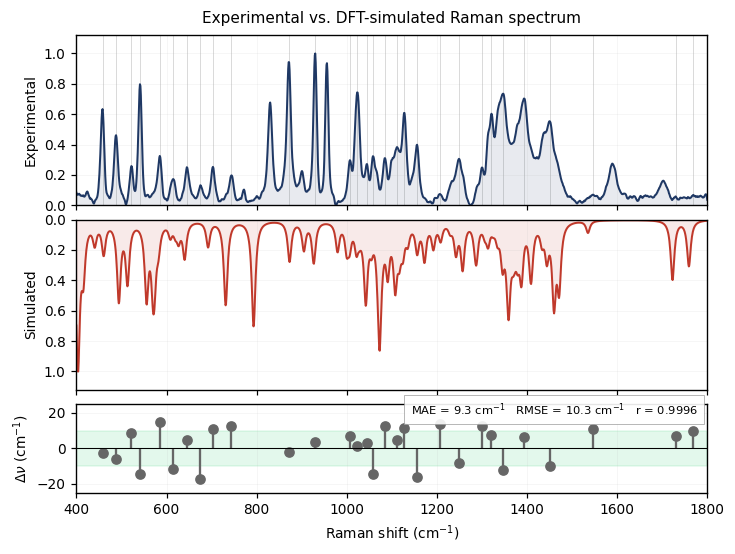

In [16]:
fig = plt.figure(figsize=(7.4, 5.4))
gs = gridspec.GridSpec(3, 1, height_ratios=[2.4, 2.4, 1.25], hspace=0.10)
b0 = fig.add_subplot(gs[0]); b1 = fig.add_subplot(gs[1], sharex=b0); b2 = fig.add_subplot(gs[2], sharex=b0)

b0.plot(GRID, mean, color=C["exp"], lw=1.3)
b0.fill_between(GRID, 0, mean, color=C["exp"], alpha=0.10)
b0.set_ylabel("Experimental"); b0.set_ylim(0, 1.12); b0.tick_params(labelbottom=False)
b0.set_title("Experimental vs. DFT-simulated Raman spectrum", fontsize=10, pad=8)

b1.plot(GRID, sim, color=C["sim"], lw=1.3)
b1.fill_between(GRID, 0, sim, color=C["sim"], alpha=0.10)
b1.set_ylabel("Simulated"); b1.set_ylim(0, 1.12); b1.tick_params(labelbottom=False); b1.invert_yaxis()

b2.stem(m.exp, m.delta, linefmt=C["grey"], markerfmt="o", basefmt=" ")
b2.axhline(0, color="k", lw=0.7); b2.axhspan(-10, 10, color=C["ok"], alpha=0.13)
b2.set_ylabel("$\\Delta\\nu$ (cm$^{-1}$)"); b2.set_xlabel("Raman shift (cm$^{-1}$)")
b2.set_ylim(-25, 25)
b2.text(0.985, 0.88,
        f"MAE = {stats['MAE']:.1f} cm$^{{-1}}$   RMSE = {stats['RMSE']:.1f} cm$^{{-1}}$   r = {stats['r']:.4f}",
        transform=b2.transAxes, ha="right", fontsize=7.5,
        bbox=dict(fc="white", ec="#999", lw=0.5, alpha=0.9))
for a in (b0, b1, b2):
    a.set_xlim(CFG["GRID_LO"], CFG["GRID_HI"]); a.grid(alpha=0.15, lw=0.5)
for r in m.itertuples(): b0.plot([r.exp, r.exp], [0, 1.12], color="#bbb", lw=0.35, zorder=0)
save(fig, "fig6_overlay"); plt.show()

## 12. The 730 cm⁻¹ region

saved  figures/fig7_region730.png


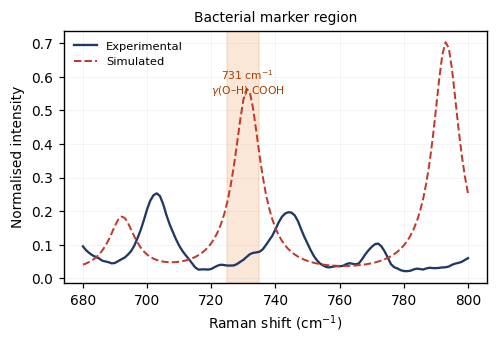

mode 41 at 731.3 cm-1
  pyranose ring : 0.5%
  heavy atoms   : 24.0%
  dominant atoms: [(38, 'H', np.float64(47.9)), (18, 'C', np.float64(14.4)), (28, 'H', np.float64(12.2)), (31, 'H', np.float64(10.9)), (7, 'O', np.float64(3.3))]
  atom 38 (H) bonded to: O6(0.97 A)


In [17]:
fig, ax = plt.subplots(figsize=(4.6, 3.2))
mk = (GRID >= 680) & (GRID <= 800)
ax.plot(GRID[mk], mean[mk], color=C["exp"], lw=1.5, label="Experimental")
ax.plot(GRID[mk], sim[mk], color=C["sim"], lw=1.3, ls="--", label="Simulated")
ax.axvspan(725, 735, color=C["warn"], alpha=0.18)

m731 = int(D.iloc[(D.freq_scaled - 731).abs().argsort().iloc[0]]["mode"])
r731 = describe_mode(m731)
ax.annotate(f"{r731['freq_scaled']:.0f} cm$^{{-1}}$\n$\\gamma$(O–H) COOH",
            (r731["freq_scaled"], 0.55), fontsize=7, ha="center", color="#a04000")
ax.set_xlabel("Raman shift (cm$^{-1}$)"); ax.set_ylabel("Normalised intensity")
ax.legend(frameon=False, fontsize=7.5); ax.grid(alpha=0.18, lw=0.5)
ax.set_title("Bacterial marker region", fontsize=9)
plt.tight_layout(); save(fig, "fig7_region730"); plt.show()

print(f"mode {m731} at {r731['freq_scaled']:.1f} cm-1")
print(f"  pyranose ring : {r731['ring_pct']:.1f}%")
print(f"  heavy atoms   : {r731['heavy_pct']:.1f}%")
print(f"  dominant atoms: {r731['top_atoms']}")
i = r731["top_atoms"][0][0]
print(f"  atom {i} ({sym[i]}) bonded to: " +
      ", ".join(f"{sym[j]}{j}({np.linalg.norm(xyz[i]-xyz[j]):.2f} A)" for j in nbr[i]))

## 13. Export tables

In [18]:
comp.round(3).to_csv(f"{TABOUT}/Table1_experiment_vs_DFT.csv", index=False)
peaks.round(4).to_csv(f"{TABOUT}/Experimental_peak_list.csv", index=False)
pd.DataFrame({"raman_shift_cm-1": GRID, "mean_intensity": mean,
              "std_dev": sd}).to_csv(f"{TABOUT}/Experimental_reference_spectrum.csv", index=False)
pd.DataFrame({"raman_shift_cm-1": GRID,
              "intensity_norm": sim}).to_csv(f"{TABOUT}/DFT_simulated_spectrum.csv", index=False)
D.round(4).to_csv(f"{TABOUT}/DFT_all_modes.csv", index=False)

with open(f"{TABOUT}/analysis_summary.json", "w") as f:
    json.dump({"config": CFG, "reference_sets": REFERENCE_SETS,
               "n_reference_spectra": len(ref_files),
               "n_bands": int(len(peaks)),
               "n_high_confidence": int(sum(peaks.quality == "high")),
               "n_tentative": int(sum(peaks.quality == "tentative")),
               "statistics": {k: float(v) for k, v in stats.items()}}, f, indent=2)

print("tables written to", TABOUT)
for f in sorted(os.listdir(TABOUT)): print("  ", f)
print("\nfigures written to", OUT)
for f in sorted(os.listdir(OUT)): print("  ", f)

tables written to tables
   DFT_all_modes.csv
   DFT_simulated_spectrum.csv
   Experimental_peak_list.csv
   Experimental_reference_spectrum.csv
   Table1_experiment_vs_DFT.csv
   analysis_summary.json

figures written to figures
   fig2_reference.png
   fig3_optimisation.png
   fig4_photostability.png
   fig5_simulated.png
   fig6_overlay.png
   fig7_region730.png
   figS1_qc_overview.png
   figS2_correlation.png
   figS3_peak_validation.png
